In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

# Crear dataset

In [7]:
## Crear Dataset Sintético
np.random.seed(42)
n_customers = 500

data = {
    'Edad': np.random.randint(18, 70, n_customers),
    'Ingreso_Anual': np.random.normal(50000, 15000, n_customers),
    'Puntaje_Gasto': np.random.randint(1, 100, n_customers),
    'Frecuencia_Compra': np.random.poisson(5, n_customers),
    'Antigüedad_Meses': np.random.randint(1, 72, n_customers),
    'Devoluciones': np.random.binomial(10, 0.1, n_customers),
    'Gasto_Electronica': np.random.uniform(0, 5000, n_customers),
    'Gasto_Hogar': np.random.uniform(0, 3000, n_customers)
}

df = pd.DataFrame(data)

## Preprocesamiento: Normalización (Vital para PCA y t-SNE)
# Las técnicas de reducción dimensional son sensibles a la escala de los datos
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

print("Dataset preparado con dimensiones:", df_scaled.shape)

Dataset preparado con dimensiones: (500, 8)


# Lección 3: Reducción Dimensional y Preprocesamiento

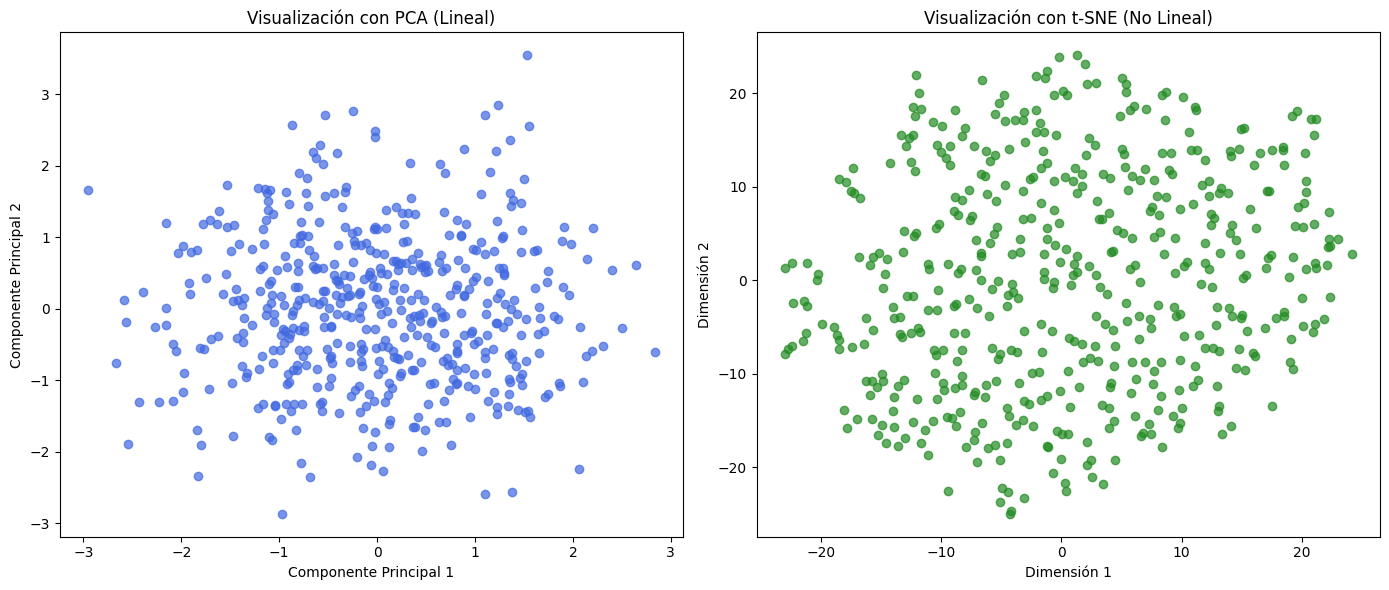

In [8]:
# Aplicar PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled)

# Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(df_scaled)

# Visualización comparativa
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(pca_results[:, 0], pca_results[:, 1], alpha=0.7, c='royalblue')
plt.title('Visualización con PCA (Lineal)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.subplot(1, 2, 2)
plt.scatter(tsne_results[:, 0], tsne_results[:, 1], alpha=0.7, c='forestgreen')
plt.title('Visualización con t-SNE (No Lineal)')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')

plt.tight_layout()
plt.show()

# Lección 4: Aplicación práctica de Clusterización con Python

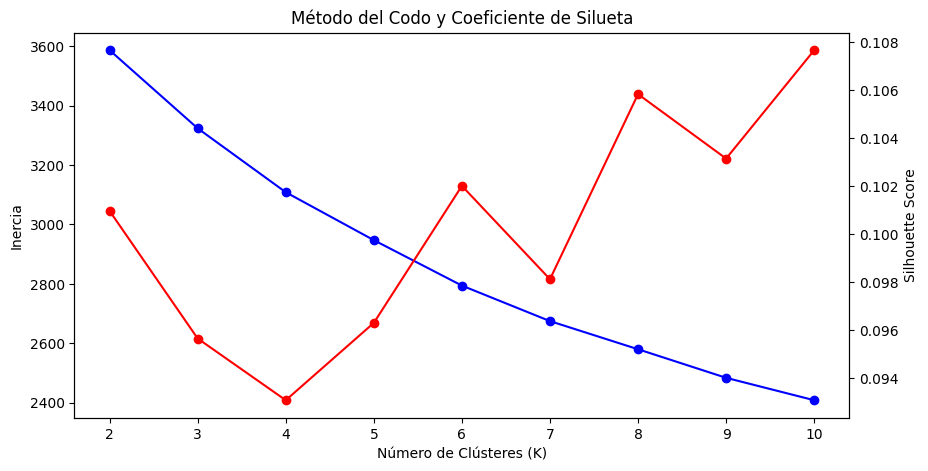

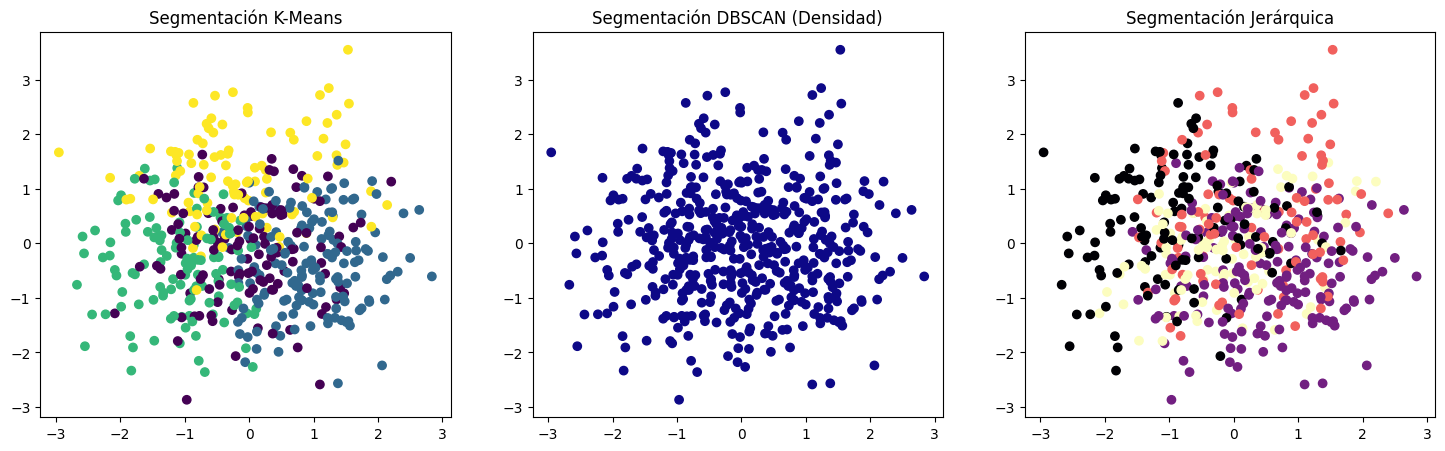

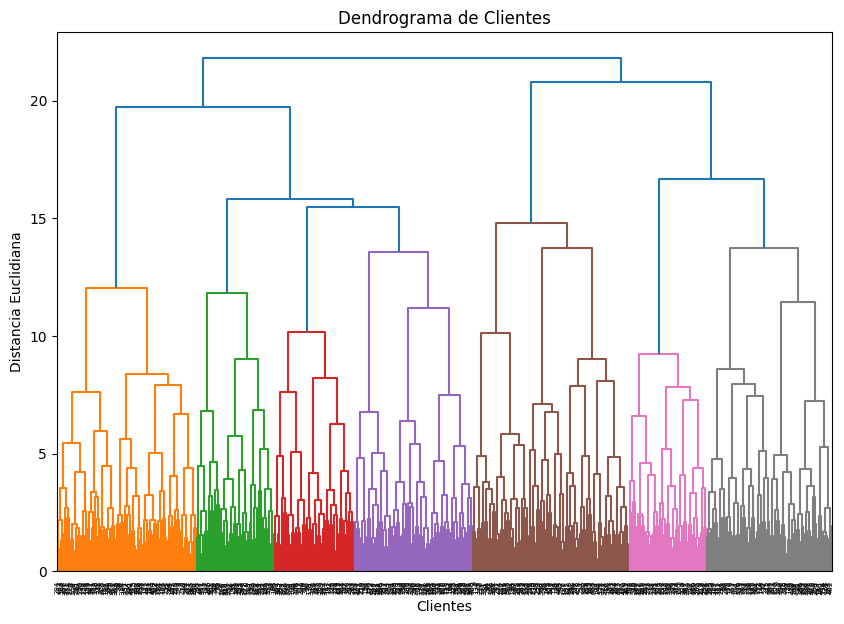

In [9]:
# --- Determinar K óptimo (Método del Codo y Silueta) ---
inertia = []
silhouette_vals = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_vals.append(silhouette_score(df_scaled, kmeans.labels_))

# Visualización de métricas
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(K_range, inertia, 'bo-', label='Inercia (Codo)')
ax1.set_xlabel('Número de Clústeres (K)')
ax1.set_ylabel('Inercia')
ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_vals, 'ro-', label='Coef. Silueta')
ax2.set_ylabel('Silhouette Score')
plt.title('Método del Codo y Coeficiente de Silueta')
plt.show()

# --- Aplicación de los 3 Algoritmos ---
# Supongamos que el óptimo es K=4 basado en las métricas anteriores
k_opt = 4

# K-Means
kmeans_final = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
labels_km = kmeans_final.fit_predict(df_scaled)

# DBSCAN (Ajustamos eps y min_samples para detectar densidad)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_db = dbscan.fit_predict(df_scaled)

# Agrupamiento Jerárquico (Ward)
hierarch = AgglomerativeClustering(n_clusters=k_opt)
labels_hj = hierarch.fit_predict(df_scaled)

# --- Visualización de Resultados (usando PCA de la Lección 3) ---
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(pca_results[:, 0], pca_results[:, 1], c=labels_km, cmap='viridis')
axs[0].set_title('Segmentación K-Means')

axs[1].scatter(pca_results[:, 0], pca_results[:, 1], c=labels_db, cmap='plasma')
axs[1].set_title('Segmentación DBSCAN (Densidad)')

axs[2].scatter(pca_results[:, 0], pca_results[:, 1], c=labels_hj, cmap='magma')
axs[2].set_title('Segmentación Jerárquica')

plt.show()

# Dendrograma para el informe
plt.figure(figsize=(10, 7))
dendrogram = sch.dendrogram(sch.linkage(df_scaled, method='ward'))
plt.title('Dendrograma de Clientes')
plt.xlabel('Clientes')
plt.ylabel('Distancia Euclidiana')
plt.show()